# preliminary fit of ALPT bias parameters

In [1]:
import os
import numpy as np
import numba as nb
from numba import njit, prange, int64

In [2]:
import matplotlib.pyplot as plt

In [3]:
from geneticalgorithm import geneticalgorithm as ga

In [4]:
np.random.seed(123456)

## read reference Quijote+HOD simulation

In [5]:
from hodalpt.sims.quijote import HODgalaxies
theta_hod = {}
theta_hod['logMmin'] = 13.0
theta_hod['sigma_logM'] = 0.4
theta_hod['logM0'] = 13.67
theta_hod['logM1'] = 13.68
theta_hod['alpha'] = 0.79
theta_hod['Abias'] = 0.0
theta_hod['eta_conc'] = 1.11
theta_hod['eta_cen'] = 0.31
theta_hod['eta_sat'] = 0.85

hod = HODgalaxies(theta_hod, '/Users/ch54662/data/simbig/quijote/fiducial_HR/0')#'/Users/chang/data/simbig/quijote/fiducial_HR/0')

/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/phase_space_models/analytic_models/satellites/nfw/biased_nfw_phase_space.py:225: UserWarning: You have selected 18 bins to digitize host halo concentration 
and 96 bins to digitize the galaxy bias parameter.
To populate mocks, the BiasedNFWPhaseSpace class builds a lookup table with shape (18, 96, 101),
one entry for every numerical solution to the Jeans equation.
Using this fine of a binning requires a long pre-computation of 174528 integrals
.Make sure you actually need to use so many bins
  warn(lookup_table_performance_warning.format(*args))
/opt/homebrew/Caskroom/miniconda/base/envs/simbig/lib/python3.11/site-packages/halotools/empirical_models/factories/hod_model_factory.py:890: UserWarning: The composite model received multiple component models 
with a new_haloprop_func_dict that use the conc_NFWmodel key. 
Ignoring the one that appears in the profile component for satellite

In [6]:
from nbodykit.lab import ArrayCatalog, FFTPower

In [7]:
data = {'Position': np.array(hod['Position'])}
cat = ArrayCatalog(data, BoxSize=1000., Nmesh=256)
galmesh = cat.to_mesh(Nmesh=256, BoxSize=1000., resampler='NEAREST', compensated=False, interlaced=True).to_real_field(normalize=False).value  # shape (nmesh, nmesh, nmesh)

In [8]:
@njit(cache=True)
def k_squared(lbox,ngrid,ii,jj,kk):
    
      kfac = 2.0*np.pi/lbox

      if ii <= ngrid/2:
        kx = kfac*ii
      else:
        kx = -kfac*(ngrid-ii)
      
      if jj <= ngrid/2:
        ky = kfac*jj
      else:
        ky = -kfac*(ngrid-jj)
      
      #if kk <= nc/2:
      kz = kfac*kk
      #else:
      #  kz = -kfac*np.float64(nc-k)
      
      k2 = kx**2+ky**2+kz**2

      return k2

@njit(cache=True)
def k_squared_nohermite(lbox,ngrid,ii,jj,kk):

      kfac = 2.0*np.pi/lbox

      if ii <= ngrid/2:
        kx = kfac*ii
      else:
        kx = -kfac*(ngrid-ii)

      if jj <= ngrid/2:
        ky = kfac*jj
      else:
        ky = -kfac*(ngrid-jj)

      if kk <= ngrid/2:
          kz = kfac*kk
      else:
          kz = -kfac*(ngrid-kk)                                                                                                           

      k2 = kx**2+ky**2+kz**2

      return k2

@njit(parallel=False, cache=True)
def get_power(fsignal, Nbin, kmax, dk, kmode, power, nmode, ngrid=256, lbox=1000.):
    
    for i in prange(ngrid):
        for j in prange(ngrid):
            for k in prange(ngrid):
                ktot = np.sqrt(k_squared_nohermite(lbox,ngrid,i,j,k))
                if ktot <= kmax:
                    nbin = int(ktot/dk-0.5)
                    akl = fsignal.real[i,j,k]
                    bkl = fsignal.imag[i,j,k]
                    kmode[nbin]+=ktot
                    power[nbin]+=(akl*akl+bkl*bkl)
                    nmode[nbin]+=1

    for m in prange(Nbin):
        if(nmode[m]>0):
            kmode[m]/=nmode[m]
            power[m]/=nmode[m]

    power = power / (ngrid/2)**3

    return kmode, power, nmode


def measure_spectrum(signal, ngrid=256, lbox=1000.):

    nbin = round(ngrid/2)
    
    fsignal = np.fft.fftn(signal) 

    kmax = np.pi * ngrid / lbox 
    dk = kmax/nbin  # Bin width

    nmode = np.zeros((nbin))
    kmode = np.zeros((nbin))
    power = np.zeros((nbin))

    kmode, power, nmode = get_power(fsignal, nbin, kmax, dk, kmode, power, nmode)
    
    return kmode[1:], power[1:]

@njit(fastmath=True, cache=True)
def negative_binomial(n, p):
    if n>0:
        if p > 0. and p < 1.:
            gfunc = np.random.gamma(n, (1. - p) / p)
            Y = np.random.poisson(gfunc)

    else:
        Y = 0

    return Y

## define bias model

In [12]:
@njit(parallel=True, cache=True, fastmath=True)
def biasmodel(ngrid, lbox, delta, tweb, twebdelta, nmean, alpha, beta, dth, rhoeps, eps, twebenv, twebdeltaenv):

    ncounts = np.zeros((ngrid,ngrid,ngrid))

    # FIRST LOOP: deterministic bias
    # Parallelize the outer loop
    for ii in prange(ngrid):
        for jj in range(ngrid):
            for kk in range(ngrid):
                 # Sample number counts
                if tweb[ii,jj,kk]==twebenv and twebdelta[ii,jj,kk]==twebdeltaenv and delta[ii,jj,kk] >= dth:
                    ncounts[ii,jj,kk] = (1.+delta[ii,jj,kk])**alpha * np.exp(-((1 + delta[ii,jj,kk])/rhoeps)**eps)# * np.exp(-((1 + delta[ii,jj,kk])/rhoepsprime)**epsprime)
                else:
                    ncounts[ii,jj,kk] = 0. #

    nc = 0.
    for ii in range(ngrid):
        for jj in range(ngrid):
            for kk in range(ngrid):
                # Sample number counts
                if tweb[ii,jj,kk]==twebenv and twebdelta[ii,jj,kk]==twebdeltaenv:
                    nc+= ncounts[ii,jj,kk]
    
    denstot = nc / lbox**3

    normal = nmean / denstot
    
    for ii in prange(ngrid):
        for jj in range(ngrid):
            for kk in range(ngrid):

                ncounts[ii,jj,kk] = nmean / denstot *  ncounts[ii,jj,kk]
                pnegbin = 1 - ncounts[ii,jj,kk]/(ncounts[ii,jj,kk] + beta)

                ncounts[ii,jj,kk] = negative_binomial(beta, pnegbin)

    return ncounts, normal

In [10]:
Ngrid = 256
Lbox = 1000.
    
dm_dir = '/Users/ch54662/data/simbig/quijote/fiducial_HR/0/alpt/'

delta = np.fromfile(os.path.join(dm_dir, 'super_deltaBox.dat'), dtype=np.float32)  # In real space
delta = np.reshape(delta, (Ngrid,Ngrid,Ngrid))

tweb = np.fromfile(os.path.join(dm_dir, 'Tweb_.dat'), dtype=np.float32)  # In real space
tweb = np.reshape(tweb, (Ngrid,Ngrid,Ngrid))

dweb = np.fromfile(os.path.join(dm_dir, 'TwebDelta_.dat'), dtype=np.float32)  # In real space 
dweb = np.reshape(dweb, (Ngrid,Ngrid,Ngrid))

print(np.amin(delta), np.amax(delta))

-1.0 186.50102


In [11]:
tweb = tweb.astype(int) - 1 
dweb = dweb.astype(int) - 1

5.2351086e-05
Fitting ...
 The best solution found:                                                                           
 [ 1.96492891 67.06129643 -0.88251063 19.99242108  1.41970262]

 Objective function:
 0.017783003131119114


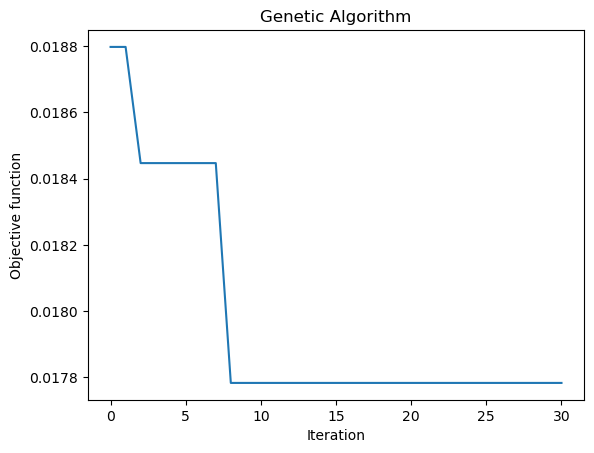

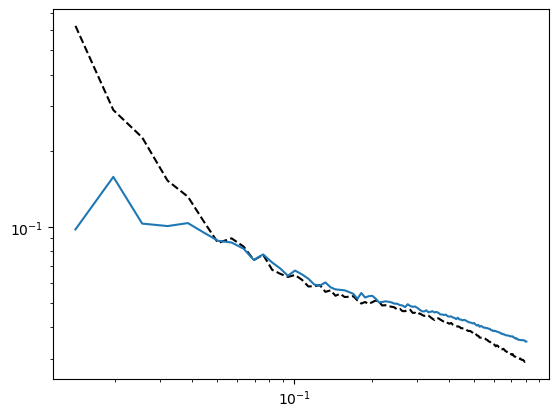

3.8145423e-05
Fitting ...
 The best solution found:                                                                           
 [ 2.38013484 17.57299147  0.23708544  9.43682763  2.22658706]

 Objective function:
 0.0008265740479768327


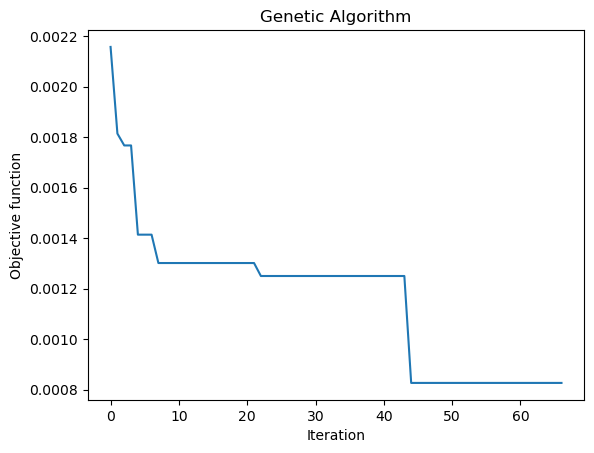

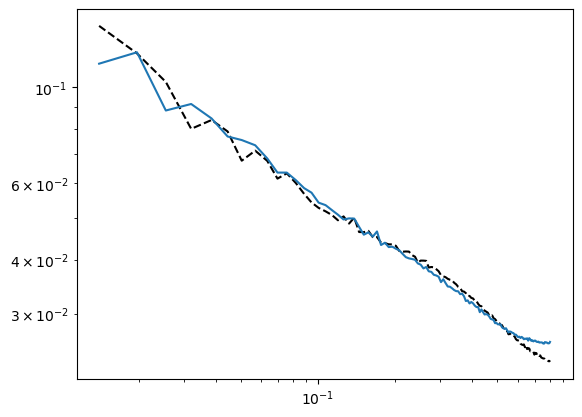

5.3554113e-06
Fitting ...
 The best solution found:                                                                           
 [ 0.72859473 48.54796142 -0.07287836 15.69245937  1.16697254]

 Objective function:
 0.0006139633885516405


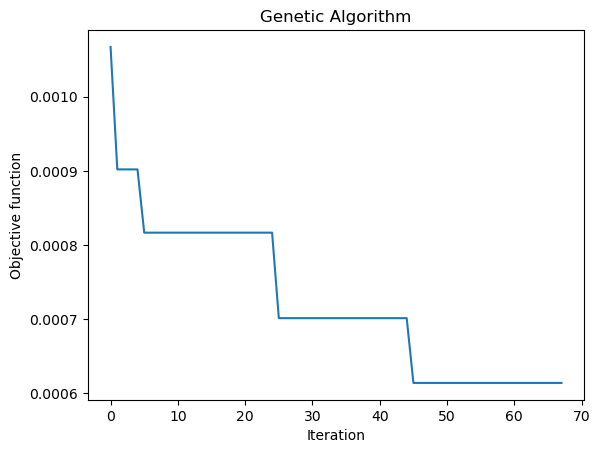

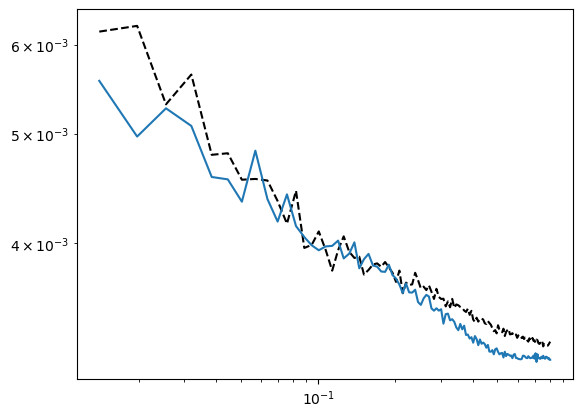

3.3174178e-08
Fitting ...
 The best solution found:                                                                           
 [ 0.45625873 31.83538154 -0.76941534 19.44022183  0.67958482]

 Objective function:
 0.0005536305489069478


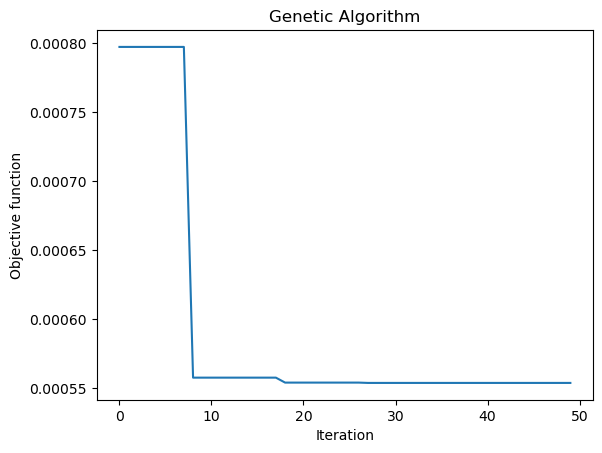

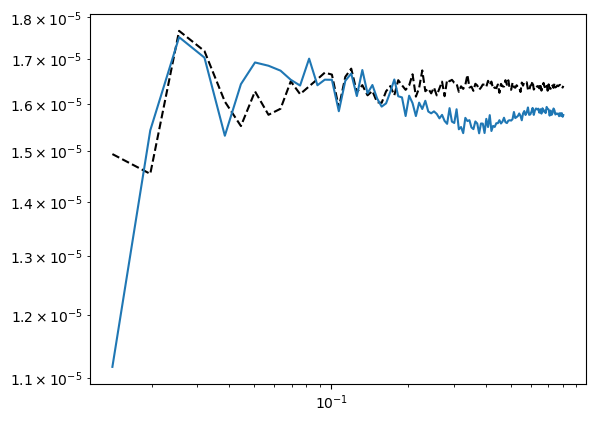

2.9649489e-05
Fitting ...
 The best solution found:                                                                           
 [ 3.31036370e-02  5.15284701e+01 -4.32474553e-01  1.53830406e+01
  2.85559404e+00]

 Objective function:
 0.1548006906694996


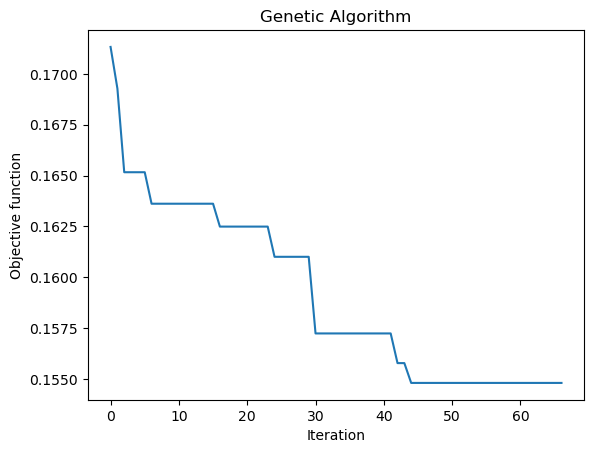

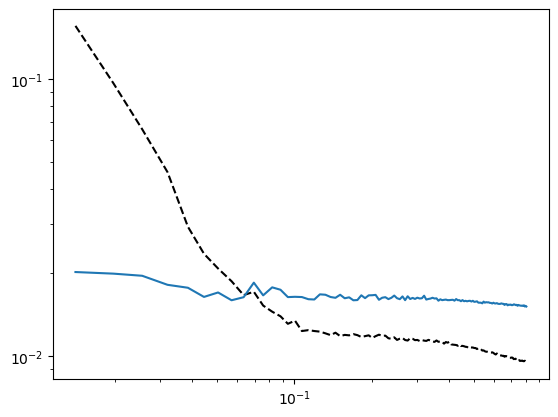

0.0001510141
Fitting ...
 The best solution found:                                                                           
 [ 2.03168342 34.21721931 -0.79960442  6.87406367  1.25704645]

 Objective function:
 0.0007764553625425503


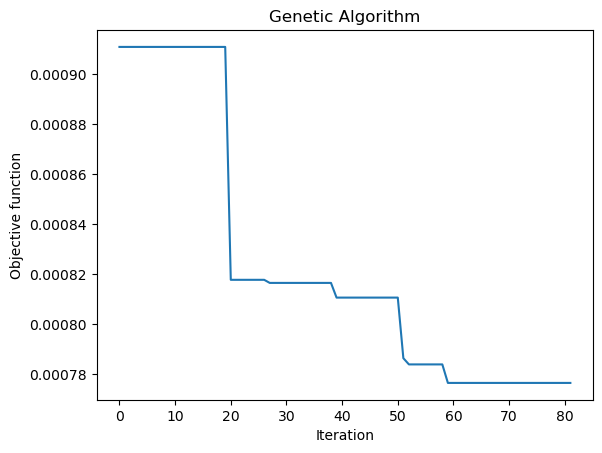

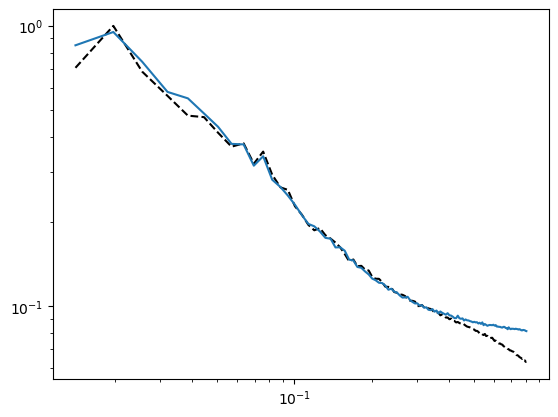

7.7290846e-05
Fitting ...
 The best solution found:                                                                           
 [ 2.21224642 44.46875767 -0.90143254  4.28731204  0.95551285]

 Objective function:
 0.0033757575155250216


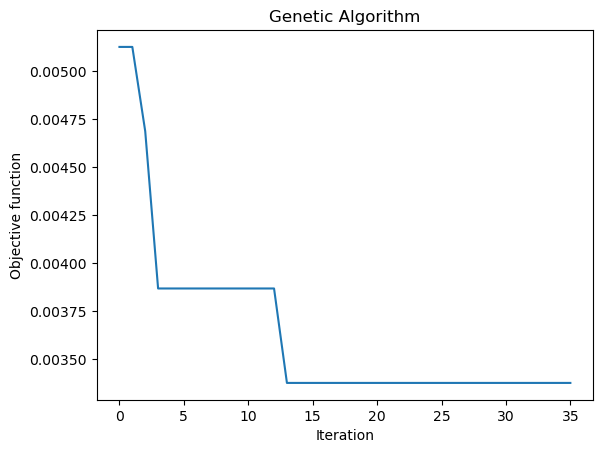

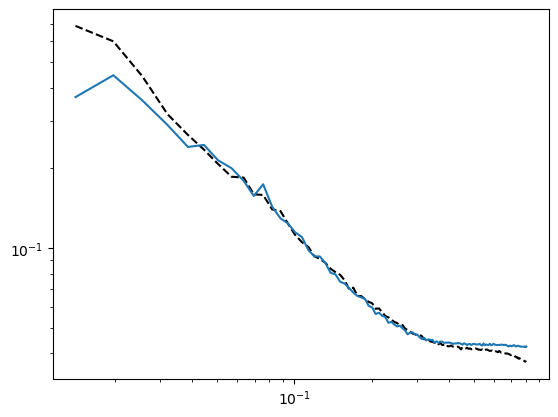

1.7703958e-06
Fitting ...
 The best solution found:                                                                           
 [ 0.19328955 89.50758497 -0.30788895  3.99179041  2.66346227]

 Objective function:
 0.0025545677616703216


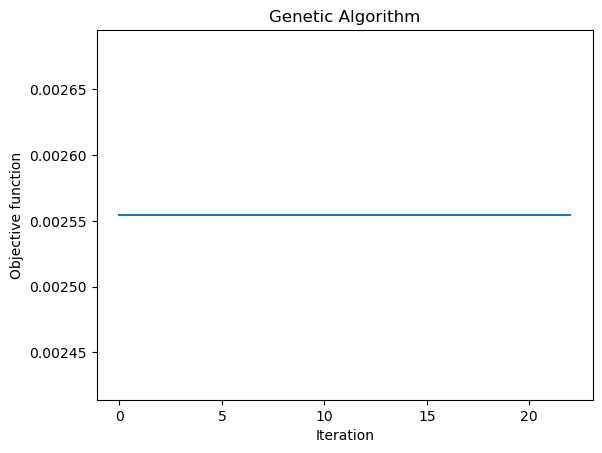

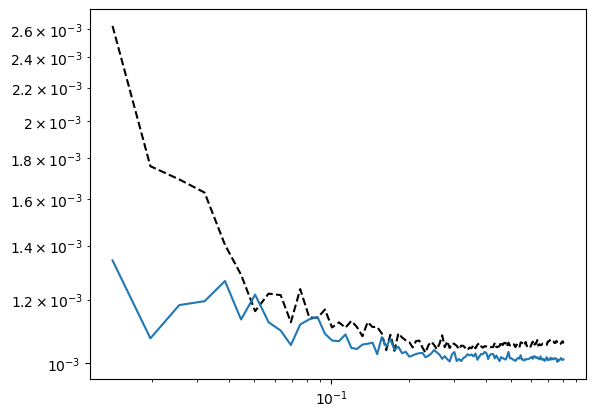

1.9229947e-06
Fitting ...
 The best solution found:                                                                           
 [ 0.46351582 27.65380062 -0.35850466 19.56026386  1.76163313]

 Objective function:
 0.09734756031081312


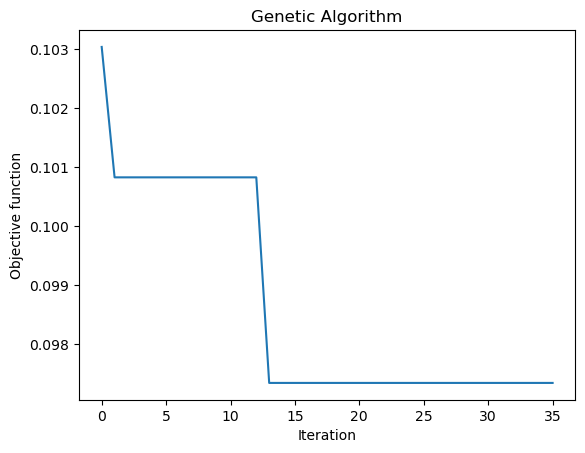

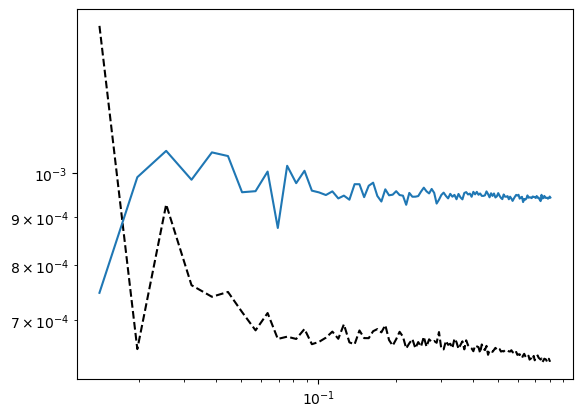

2.2474735e-05
Fitting ...
 The best solution found:                                                                           
 [ 0.8864895  93.5794849  -0.71901785 13.41307075  0.29736718]

 Objective function:
 0.011589981032155779


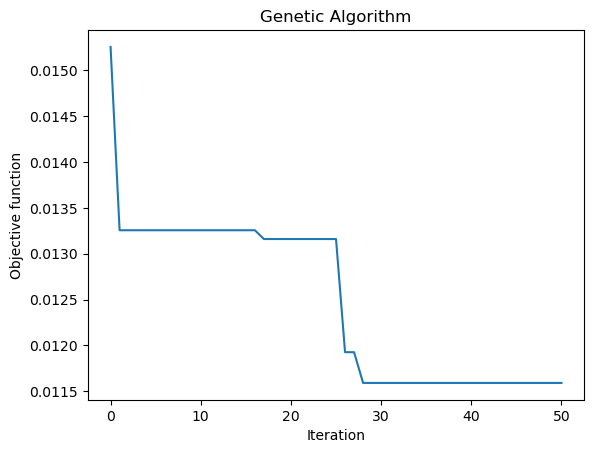

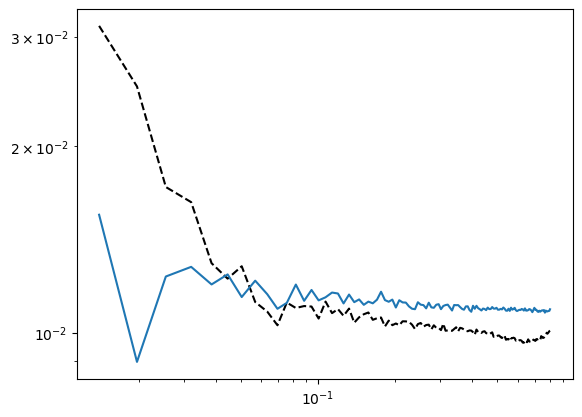

4.2555923e-05
Fitting ...
 The best solution found:                                                                           
 [ 1.42207614e+00  6.10060833e+01 -2.89101424e-02  1.66425255e+01
  2.20714802e+00]

 Objective function:
 0.03381891181766735


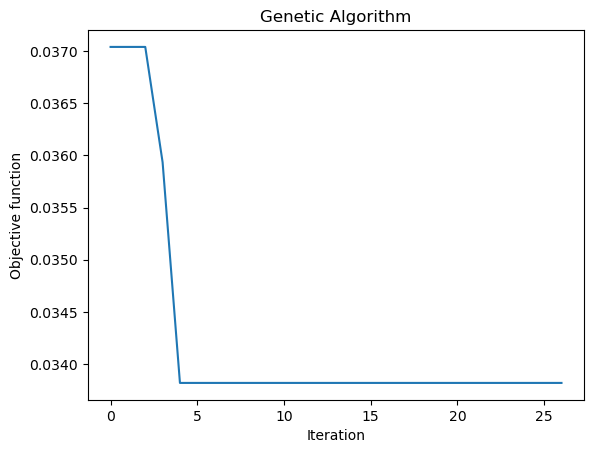

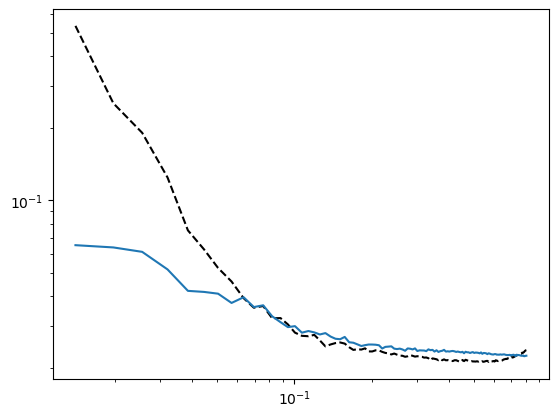

1.6457553e-06
Fitting ...
 The best solution found:                                                                           
 [ 2.73046151e+00  5.10513428e+01 -1.34504798e-02  1.83095924e+01
  2.01924383e+00]

 Objective function:
 0.004559683498833939


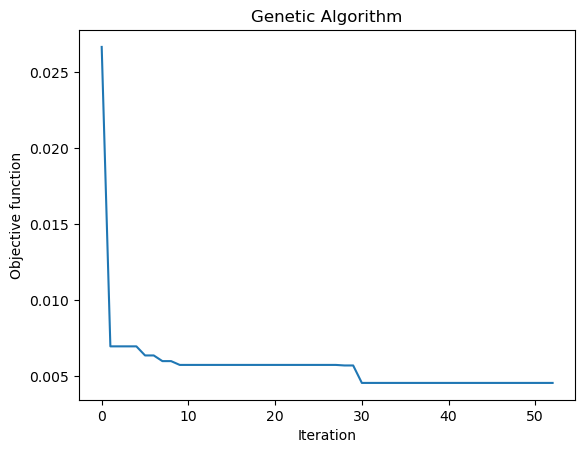

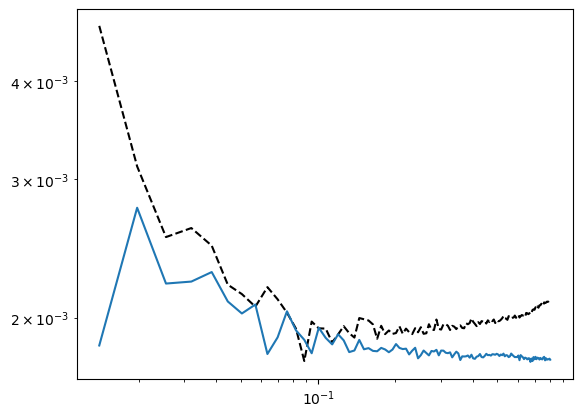

2.0305942e-08
Fitting ...
||||||||||||||||||________________________________ 35.0% GA is running...

KeyboardInterrupt: 

In [22]:
kkth = 0.5

for itweb in range(4): 
    for idweb in range(4): 
        
        alpha_bounds = (0.01, 3.)
        beta_bounds = (0.1, 100.)
        dth_bounds = (-1, 0.5)
        rhoeps_bounds = (0.3, 20.)
        eps_bounds = (0.1, 3.)
        bounds = np.array([alpha_bounds, beta_bounds, dth_bounds, rhoeps_bounds, eps_bounds])
        
        meandens = np.sum(galmesh[np.logical_and(tweb==itweb, dweb==idweb)])/Lbox**3
        print(meandens)
        
        ncounts_mask = np.zeros((Ngrid,Ngrid,Ngrid))
        ncounts_mask[np.logical_and(tweb==itweb, dweb==idweb)] = galmesh[np.logical_and(tweb==itweb, dweb==idweb)]
        
        kkgal, pkgal = measure_spectrum(ncounts_mask)
        
        def _chisquare(xx): 
            # Define the parameters to fit
            alpha = xx[0]
            beta = xx[1]
            dth = xx[2]
            rhoeps = xx[3]
            eps = xx[4]
            
            ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, alpha, beta, dth, rhoeps, eps, itweb, idweb)
        
            ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
            ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]
        
            kk, pk = measure_spectrum(ncounts_new_mask)
        
            return np.sum((pk[np.where(kk < kkth)]/pkgal[np.where(kk < kkth)] - 1.)**2)/len(pk[np.where(kk<kkth)]) 
        
        print('Fitting ...')
        algorithm_param = {'max_num_iteration': 100,
                   'population_size':100,
                   'mutation_probability':0.1,
                   'elit_ratio': 0.01,
                   'crossover_probability': 0.5,
                   'parents_portion': 0.3,
                   'crossover_type':'uniform',
                   'max_iteration_without_improv':20}
            
        model=ga(function=_chisquare, 
                 dimension=5,
                 variable_type='real', 
                 variable_boundaries=bounds, 
                 algorithm_parameters=algorithm_param)
        model.run()
        convergence = model.report
        solution = model.output_dict
            
        x0new = solution['variable']
        
        ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, x0new[0], x0new[1], x0new[2], x0new[3], x0new[4], itweb, idweb)
        ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
        ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]
        
        kk, pk = measure_spectrum(ncounts_new_mask)
        
        plt.loglog(kkgal, pkgal, c='k', ls='--')
        plt.loglog(kk, pk)
        plt.show()

## check impact of `dth`

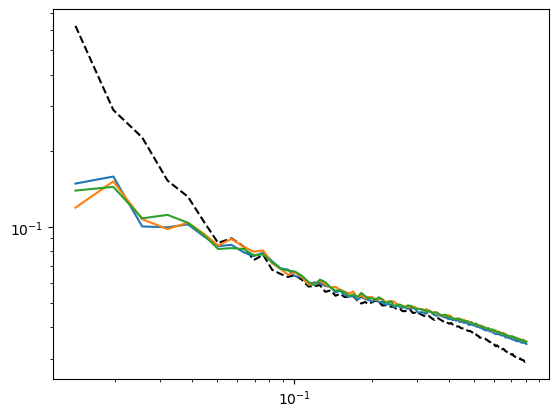

In [29]:
kkth = 0.5

itweb = 0 
idweb = 0 

ncounts_mask = np.zeros((Ngrid,Ngrid,Ngrid))
ncounts_mask[np.logical_and(tweb==itweb, dweb==idweb)] = galmesh[np.logical_and(tweb==itweb, dweb==idweb)]

kkgal, pkgal = measure_spectrum(ncounts_mask)

plt.loglog(kkgal, pkgal, c='k', ls='--')

meandens = 5.2351086e-05
x0new = np.array([1.96492891, 67.06129643, -0.88251063, 19.99242108, 1.41970262])
ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, x0new[0], x0new[1], x0new[2], x0new[3], x0new[4], itweb, idweb)
ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]
kk, pk = measure_spectrum(ncounts_new_mask)
plt.loglog(kk, pk)


x0new = np.array([1.96492891, 67.06129643, -1, 19.99242108, 1.41970262])
ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, x0new[0], x0new[1], x0new[2], x0new[3], x0new[4], itweb, idweb)
ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]
kk, pk = measure_spectrum(ncounts_new_mask)
plt.loglog(kk, pk)


x0new = np.array([1.96492891, 67.06129643, 1, 19.99242108, 1.41970262])
ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, x0new[0], x0new[1], x0new[2], x0new[3], x0new[4], itweb, idweb)
ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]
kk, pk = measure_spectrum(ncounts_new_mask)

plt.loglog(kk, pk)
plt.show()

not a very significant effect. Lets remove it

5.2351086e-05
Fitting ...
 The best solution found:                                                                           
 [ 2.41337761 83.25668587 12.39516645  1.12914758]

 Objective function:
 0.017478473683285416


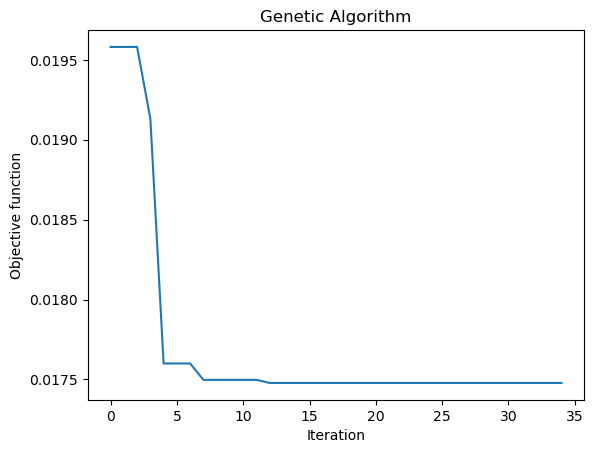

IndexError: index 4 is out of bounds for axis 0 with size 4

In [31]:
itweb = 0 
idweb = 0 

alpha_bounds = (0.01, 3.)
beta_bounds = (0.1, 100.)
rhoeps_bounds = (0.3, 20.)
eps_bounds = (0.1, 3.)
bounds = np.array([alpha_bounds, beta_bounds, rhoeps_bounds, eps_bounds])

meandens = np.sum(galmesh[np.logical_and(tweb==itweb, dweb==idweb)])/Lbox**3
print(meandens)

ncounts_mask = np.zeros((Ngrid,Ngrid,Ngrid))
ncounts_mask[np.logical_and(tweb==itweb, dweb==idweb)] = galmesh[np.logical_and(tweb==itweb, dweb==idweb)]

kkgal, pkgal = measure_spectrum(ncounts_mask)

def _chisquare(xx): 
    # Define the parameters to fit
    alpha = xx[0]
    beta = xx[1]
    rhoeps = xx[2]
    eps = xx[3]
    
    ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, alpha, beta, -1, rhoeps, eps, itweb, idweb)

    ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
    ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]

    kk, pk = measure_spectrum(ncounts_new_mask)

    return np.sum((pk[np.where(kk < kkth)]/pkgal[np.where(kk < kkth)] - 1.)**2)/len(pk[np.where(kk<kkth)]) 

print('Fitting ...')
algorithm_param = {'max_num_iteration': 100,
           'population_size':100,
           'mutation_probability':0.1,
           'elit_ratio': 0.01,
           'crossover_probability': 0.5,
           'parents_portion': 0.3,
           'crossover_type':'uniform',
           'max_iteration_without_improv':20}
    
model=ga(function=_chisquare, 
         dimension=4,
         variable_type='real', 
         variable_boundaries=bounds, 
         algorithm_parameters=algorithm_param)
model.run()
convergence = model.report
solution = model.output_dict
    
x0new = solution['variable']

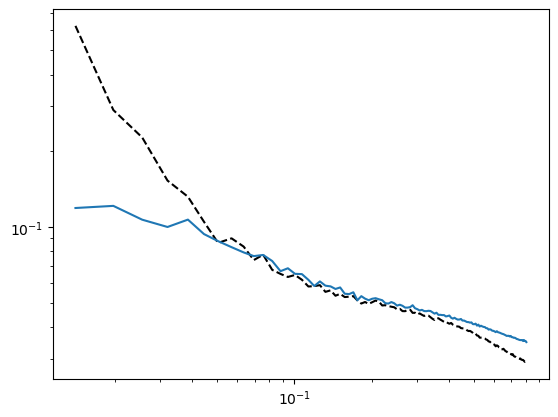

In [33]:
ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, x0new[0], x0new[1], -1, x0new[2], x0new[3], itweb, idweb)
ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]

kk, pk = measure_spectrum(ncounts_new_mask)

plt.loglog(kkgal, pkgal, c='k', ls='--')
plt.loglog(kk, pk)
plt.show()

2.9649489e-05
Fitting ...
 The best solution found:                                                                           
 [ 0.1400723  36.21492499 18.30437824  2.00440837]

 Objective function:
 0.15854277232153405


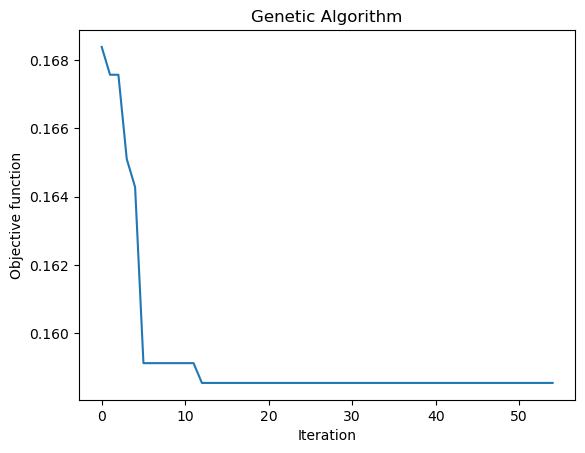

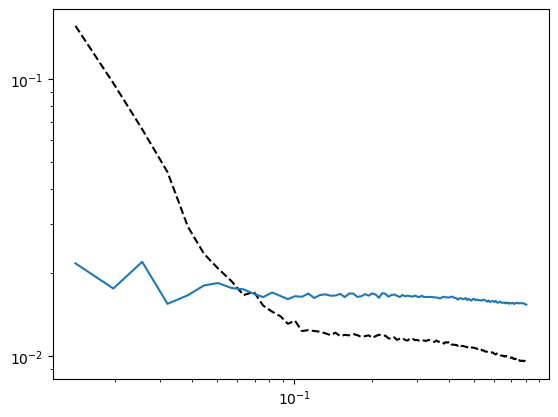

In [35]:
itweb = 1
idweb = 0 

alpha_bounds = (0.01, 3.)
beta_bounds = (0.1, 100.)
rhoeps_bounds = (0.3, 20.)
eps_bounds = (0.1, 3.)
bounds = np.array([alpha_bounds, beta_bounds, rhoeps_bounds, eps_bounds])

meandens = np.sum(galmesh[np.logical_and(tweb==itweb, dweb==idweb)])/Lbox**3
print(meandens)

ncounts_mask = np.zeros((Ngrid,Ngrid,Ngrid))
ncounts_mask[np.logical_and(tweb==itweb, dweb==idweb)] = galmesh[np.logical_and(tweb==itweb, dweb==idweb)]

kkgal, pkgal = measure_spectrum(ncounts_mask)

def _chisquare(xx): 
    # Define the parameters to fit
    alpha = xx[0]
    beta = xx[1]
    rhoeps = xx[2]
    eps = xx[3]
    
    ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, alpha, beta, -1, rhoeps, eps, itweb, idweb)

    ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
    ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]

    kk, pk = measure_spectrum(ncounts_new_mask)

    return np.sum((pk[np.where(kk < kkth)]/pkgal[np.where(kk < kkth)] - 1.)**2)/len(pk[np.where(kk<kkth)]) 

print('Fitting ...')
algorithm_param = {'max_num_iteration': 200,
           'population_size':100,
           'mutation_probability':0.1,
           'elit_ratio': 0.01,
           'crossover_probability': 0.5,
           'parents_portion': 0.3,
           'crossover_type':'uniform',
           'max_iteration_without_improv':40}
    
model=ga(function=_chisquare, 
         dimension=4,
         variable_type='real', 
         variable_boundaries=bounds, 
         algorithm_parameters=algorithm_param)
model.run()
convergence = model.report
solution = model.output_dict
    
x0new = solution['variable']

ncounts_new, normalization = biasmodel(Ngrid, Lbox, delta, tweb, dweb, meandens, x0new[0], x0new[1], -1, x0new[2], x0new[3], itweb, idweb)
ncounts_new_mask = np.zeros((Ngrid, Ngrid, Ngrid))
ncounts_new_mask[np.logical_and(tweb==itweb, dweb==idweb)] = ncounts_new[np.logical_and(tweb==itweb, dweb==idweb)]

kk, pk = measure_spectrum(ncounts_new_mask)

plt.loglog(kkgal, pkgal, c='k', ls='--')
plt.loglog(kk, pk)
plt.show()